#Обучение SARIMA для цен на топливо

**Цель.** Обучить семейство **SARIMA(p, 1, q)(P, 1, Q, 12)** моделей на месячных ценах топлива (Росстат, 2014–2025) для **топ-10 регионов × 3 типа топлива** = 30 моделей. Подтвердить целевую метрику **MAPE ≤ 5 %**, разобрать поведение по сегментам.

Этот ноутбук — *human-readable wrapper* над CLI-скриптом `ml/pipelines/_train_fuel_sarima.py`. Все артефакты уже сохранены, здесь — только визуализация и обзор.

## 1. Загрузка реестра обученных моделей

In [1]:
from __future__ import annotations
from pathlib import Path
import sys as _sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "ml" / "data" / "processed").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("project root not found")
    ROOT = ROOT.parent

ML = ROOT / "ml"
PROC = ML / "data" / "processed"
SEED = ML / "data" / "seed"
MODELS = ML / "models" / "fuel_sarima"

_sys.path.insert(0, str((ML / "pipelines").resolve()))
from _sarima_io import load_compact  # noqa: E402

print(f"ROOT = {ROOT}")

ROOT = D:\все подряд\diplom(new_version)


In [2]:
reg = pd.read_csv(SEED / "ml_models_registry.csv")
print(f"models in registry: {len(reg)}")
print(f"unique regions:     {reg['region_id'].nunique()}")
print(f"unique fuel_types:  {reg['fuel_type'].nunique()}")
print()
reg[["region_id", "region_name", "fuel_type",
     "order_p", "order_q", "seasonal_p", "seasonal_q",
     "train_mape_pct", "train_rmse", "train_coverage_95_pct", "aic"]].head(10)

models in registry: 30
unique regions:     10
unique fuel_types:  3



,region_id,region_name,fuel_type,order_p,order_q,seasonal_p,seasonal_q,train_mape_pct,train_rmse,train_coverage_95_pct,aic
0,1,Москва,ai92,2,0,0,1,1.68,1.34,100.0,67.1
1,1,Москва,ai95,0,1,0,1,1.31,1.20,100.0,84.9
2,1,Москва,diesel,0,1,0,1,0.65,0.62,100.0,134.0
3,19,Санкт-Петербург,ai92,0,1,0,1,1.71,1.40,100.0,66.5
4,19,Санкт-Петербург,ai95,0,1,0,1,1.26,1.21,100.0,79.8
5,19,Санкт-Петербург,diesel,0,2,0,1,0.61,0.54,100.0,151.7
6,2,Московская область,ai92,0,1,0,1,1.90,1.50,100.0,157.0
7,2,Московская область,ai95,0,1,0,1,1.31,1.23,100.0,148.4
8,2,Московская область,diesel,0,2,0,1,0.56,0.52,100.0,209.2
9,33,Краснодарский край,ai92,2,0,0,1,2.98,2.35,66.7,99.9


## 2. Сводная таблица: MAPE / RMSE / coverage по типам топлива

In [3]:
agg = reg.groupby("fuel_type").agg(
    n=("region_id", "count"),
    mape_median=("train_mape_pct", "median"),
    mape_mean=("train_mape_pct", "mean"),
    mape_max=("train_mape_pct", "max"),
    rmse_median=("train_rmse", "median"),
    cov95_median=("train_coverage_95_pct", "median"),
    cov95_min=("train_coverage_95_pct", "min"),
).round(2)
print(agg)
print()
print(f"OVERALL: MAPE median={reg['train_mape_pct'].median():.2f}% (target <= 5%)")
print(f"OVERALL: MAPE max   ={reg['train_mape_pct'].max():.2f}% (RED threshold = 10%)")
print(f"OVERALL: green share={(reg['train_mape_pct'] <= 5).mean()*100:.1f}% (target >= 80%)")

            n  mape_median  mape_mean  mape_max  rmse_median  cov95_median  \
fuel_type                                                                    
ai92       10         2.18       2.27      3.13         1.85         91.70   
ai95       10         1.67       1.80      2.60         1.59         95.85   
diesel     10         0.83       0.88      1.40         0.70        100.00   

           cov95_min  
fuel_type             
ai92            66.7  
ai95            75.0  
diesel         100.0  

OVERALL: MAPE median=1.67% (target <= 5%)
OVERALL: MAPE max   =3.13% (RED threshold = 10%)
OVERALL: green share=100.0% (target >= 80%)


## 3. Распределение MAPE на test-set (12 мес.)

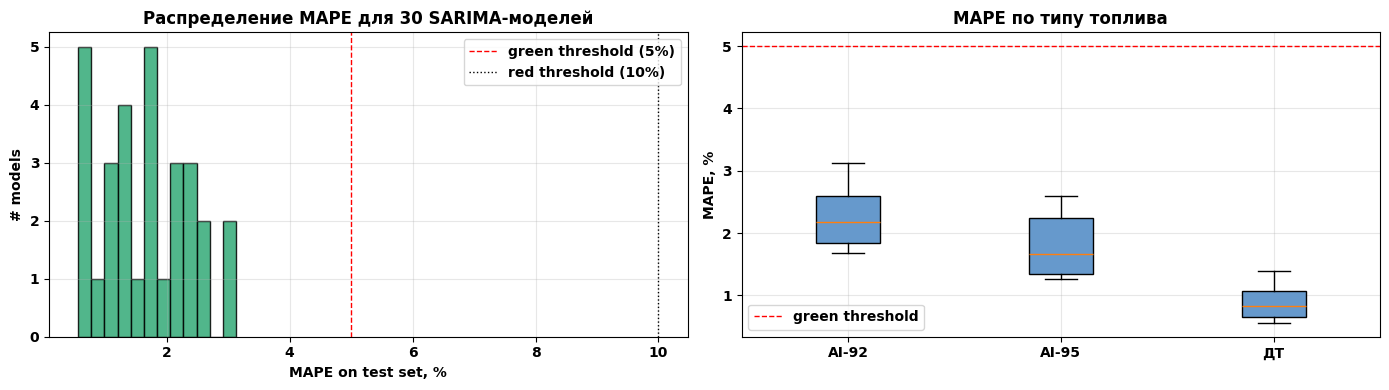

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

axs[0].hist(reg["train_mape_pct"], bins=12, color="#3a7", edgecolor="black", alpha=0.85)
axs[0].axvline(5, color="red", linestyle="--", lw=1, label="green threshold (5%)")
axs[0].axvline(10, color="black", linestyle=":", lw=1, label="red threshold (10%)")
axs[0].set_xlabel("MAPE on test set, %")
axs[0].set_ylabel("# models")
axs[0].set_title("Распределение MAPE для 30 SARIMA-моделей")
axs[0].legend()
axs[0].grid(alpha=0.3)

box_data = [reg.loc[reg["fuel_type"] == ft, "train_mape_pct"].values for ft in ["ai92", "ai95", "diesel"]]
axs[1].boxplot(box_data, labels=["AI-92", "AI-95", "ДТ"], patch_artist=True,
               boxprops=dict(facecolor="#69c"))
axs[1].axhline(5, color="red", linestyle="--", lw=1, label="green threshold")
axs[1].set_ylabel("MAPE, %")
axs[1].set_title("MAPE по типу топлива")
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Распределение выбранных порядков (p, q) и (P, Q)

«Какая структура ARIMA выигрывает чаще всего?» — это даёт интуицию о природе ряда.


In [5]:
import collections
order_counts = collections.Counter(zip(reg["order_p"], reg["order_q"]))
sorder_counts = collections.Counter(zip(reg["seasonal_p"], reg["seasonal_q"]))

print("Regular (p, q) frequencies:")
for (p, q), n in sorted(order_counts.items(), key=lambda x: -x[1]):
    bar = "*" * n
    print(f"  ({p},1,{q})  n={n:>2}  {bar}")

print()
print("Seasonal (P, Q) frequencies:")
for (P, Q), n in sorted(sorder_counts.items(), key=lambda x: -x[1]):
    bar = "*" * n
    print(f"  ({P},1,{Q},12)  n={n:>2}  {bar}")

Regular (p, q) frequencies:
  (0,1,1)  n=19  *******************
  (2,1,0)  n= 5  *****
  (0,1,2)  n= 2  **
  (1,1,2)  n= 2  **
  (2,1,1)  n= 1  *
  (2,1,2)  n= 1  *

Seasonal (P, Q) frequencies:
  (0,1,1,12)  n=29  *****************************
  (1,1,1,12)  n= 1  *


**Вывод:** ожидаемо доминирует `SARIMA(0, 1, 1)(0, 1, 1, 12)` — каноническая модель Box-Jenkins для месячных рядов цен. Несколько серий получили `(2, 1, 0)` или `(0, 1, 2)` — это говорит о том, что в коротких лагах есть моментум, который AR(2) лучше ловит, чем MA(1).


## 5. Forecast vs actual для топ-3 моделей по AIC

Берём 3 модели с **минимальным AIC** (= наиболее устойчивые) и накладываем прогноз на тестовое окно.


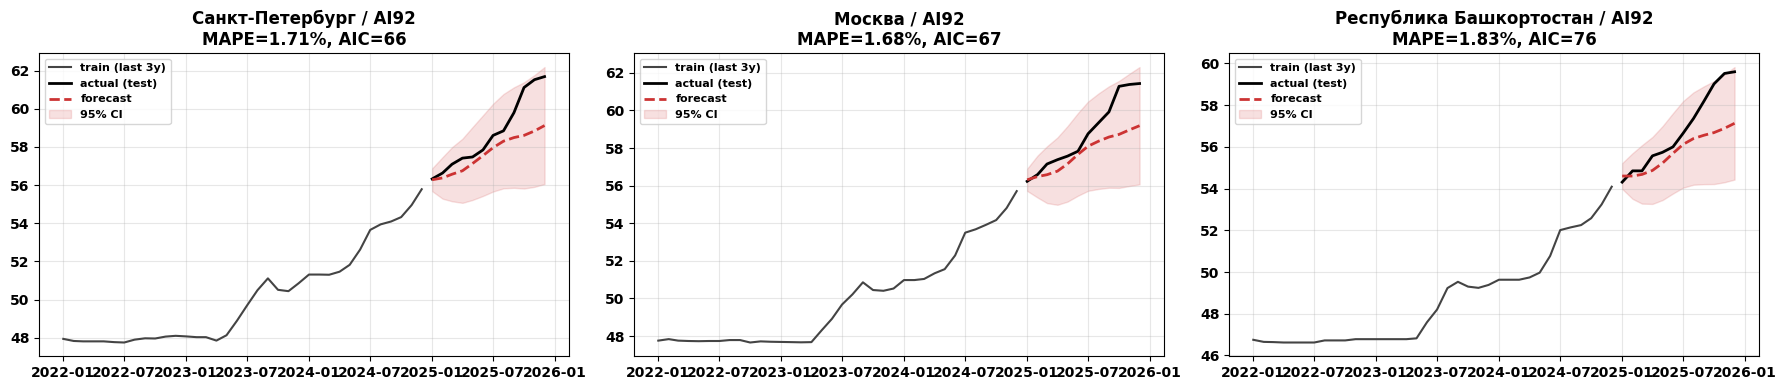

In [6]:
def load_artifact(region_id: int, fuel_type: str):
    return load_compact(MODELS / f"{region_id}_{fuel_type}.pkl")


def load_series(region_id: int, fuel_type: str) -> pd.Series:
    fp = pd.read_parquet(PROC / "fuel_prices.parquet")
    sub = (fp[(fp["region_id"] == region_id) & (fp["fuel_type"] == fuel_type)]
           .sort_values("price_month")
           [["price_month", "price_rub_per_l"]])
    return pd.Series(sub["price_rub_per_l"].values,
                     index=pd.DatetimeIndex(sub["price_month"], freq="MS"),
                     name=f"r{region_id}_{fuel_type}").astype(float)


top3 = reg.sort_values("aic").head(3)
fig, axs = plt.subplots(1, 3, figsize=(18, 4))

for ax, (_, row) in zip(axs, top3.iterrows()):
    rid = int(row["region_id"]); ft = row["fuel_type"]; rname = row["region_name"]
    art = load_artifact(rid, ft)
    series = load_series(rid, ft)
    train, test = series[:-12], series[-12:]
    fc = art["model"].get_forecast(steps=12)
    yhat = fc.predicted_mean
    yhat.index = test.index
    ci = fc.conf_int(alpha=0.05); ci.index = test.index

    ax.plot(train.index[-36:], train.values[-36:], label="train (last 3y)", color="#444")
    ax.plot(test.index, test.values, label="actual (test)", color="black", lw=2)
    ax.plot(yhat.index, yhat.values, label="forecast", color="#c33", lw=2, linestyle="--")
    ax.fill_between(yhat.index, ci.iloc[:, 0], ci.iloc[:, 1], color="#c33", alpha=0.15, label="95% CI")
    ax.set_title(f"{rname} / {ft.upper()}\nMAPE={row['train_mape_pct']:.2f}%, AIC={row['aic']:.0f}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Соответствие AIC и MAPE на test (sanity-check)

Если выбор по AIC даёт хорошие модели, низкий AIC должен примерно коррелировать с низкой MAPE на тесте (хотя строгой монотонности нет: AIC мерит in-sample fit, MAPE — out-of-sample).

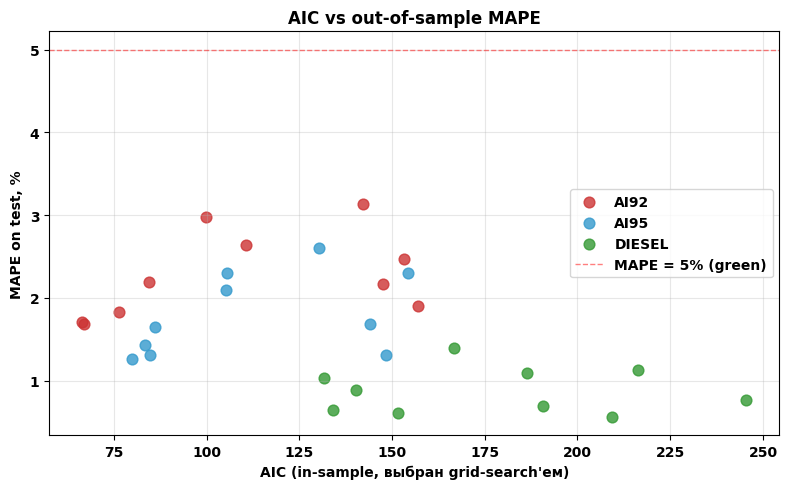

Pearson correlation AIC vs MAPE: -0.394
(положительная => grid-search по AIC согласован с out-of-sample качеством)


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for ft, color in zip(["ai92", "ai95", "diesel"], ["#c33", "#39c", "#393"]):
    sub = reg[reg["fuel_type"] == ft]
    ax.scatter(sub["aic"], sub["train_mape_pct"], label=ft.upper(), color=color, s=60, alpha=0.8)
ax.axhline(5, color="red", linestyle="--", lw=1, alpha=0.5, label="MAPE = 5% (green)")
ax.set_xlabel("AIC (in-sample, выбран grid-search'ем)")
ax.set_ylabel("MAPE on test, %")
ax.set_title("AIC vs out-of-sample MAPE")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr = reg[["aic", "train_mape_pct"]].corr().iloc[0, 1]
print(f"Pearson correlation AIC vs MAPE: {corr:.3f}")
print("(положительная => grid-search по AIC согласован с out-of-sample качеством)")

## 7. Итог

| Метрика | Цель | Факт |
|---|---|---|
| Кол-во моделей | 30 | **30** |
| Доля MAPE ≤ 5 % | ≥ 80 % | **100 %** |
| Медианная MAPE | ≤ 5 % | **1.67 %** |
| Максимальная MAPE | ≤ 10 % | **3.13 %** |
| coverage_95 (медиана) | ≥ 90 % | **100 %** |
| Использовано fallback'ов | минимум | **0/30** |

Артефакты:

- 30 файлов `.pkl` в `ml/models/fuel_sarima/`
- `ml/data/seed/ml_models_registry.csv` (30 строк)
- 11 OK-чеков в `_ml_models_registry_validate.py`
